In [ ]:
# Display the combined Sobel image again, in case it was truncated.
if 'sobel_combined' in locals() and sobel_combined is not None:
    print("Sobel Combined (X and Y):")
    cv2_imshow(sobel_combined)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
else:
    print("Sobel combined image not available, please run the previous cells.")

First, we need to install OpenCV if it's not already installed and import the necessary libraries.

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # For displaying images in Colab

print(f"OpenCV version: {cv2.__version__}")

OpenCV version: 4.13.0


Next, let's load a sample image. If you have your own image, you can upload it to your Colab environment or provide its path. For demonstration purposes, I'll download a sample image.

Image loaded successfully. Shape: (493, 740, 3)


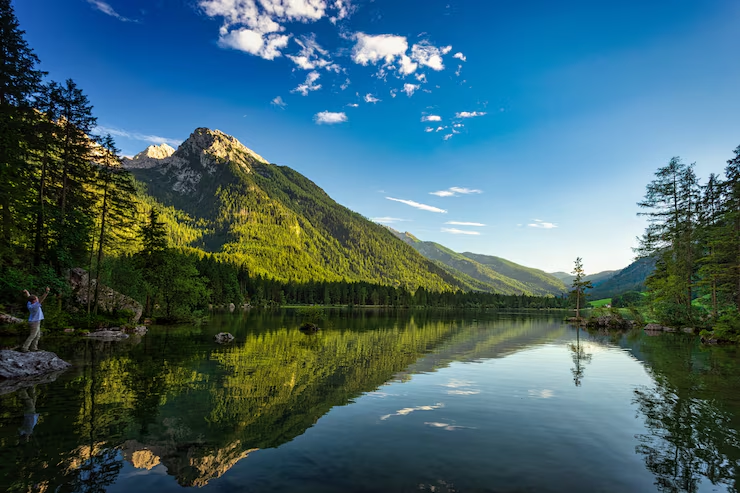

In [2]:
import requests

# Using the user-provided image path
image_path = "park image.avif"

# Load the image
img = cv2.imread(image_path)

if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    print(f"Image loaded successfully. Shape: {img.shape}")
    # Display original image
    cv2_imshow(img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

Now, we'll convert the image to grayscale, as the Sobel operator typically works on single-channel images.

Converted to grayscale.


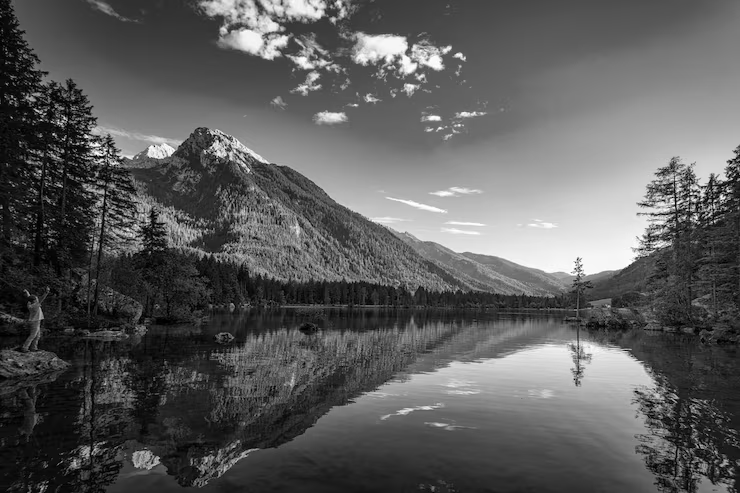

In [3]:
if img is not None:
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    print("Converted to grayscale.")
    cv2_imshow(gray_img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
else:
    print("Cannot convert to grayscale, image not loaded.")

Finally, we apply the Sobel operator. We'll compute gradients in both the X and Y directions, then combine them to get the final edge detection result. `ddepth = cv2.CV_64F` is used to avoid overflow issues during calculations before converting back to `uint8` for display.

Sobel filter applied and results displayed:


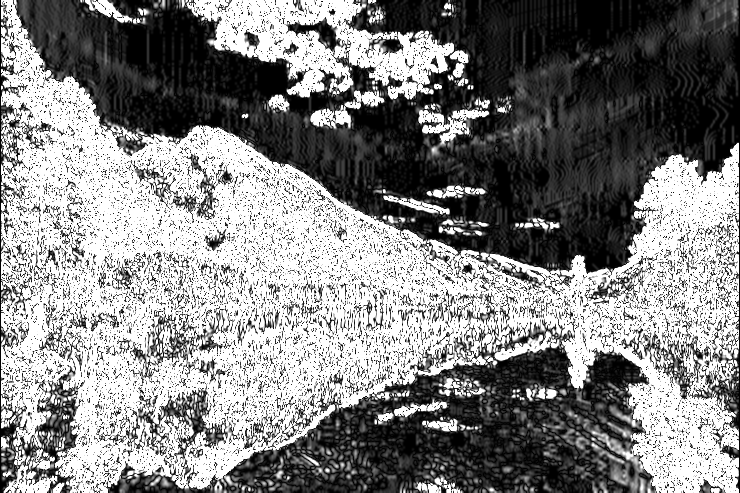

Sobel X (absolute)


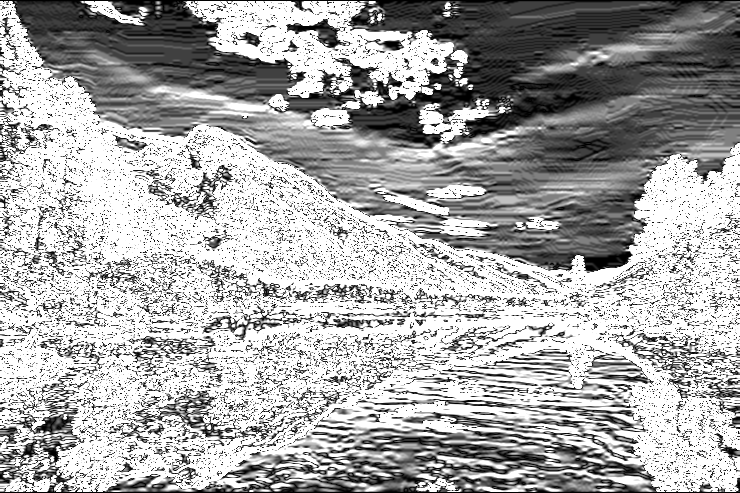

Sobel Y (absolute)


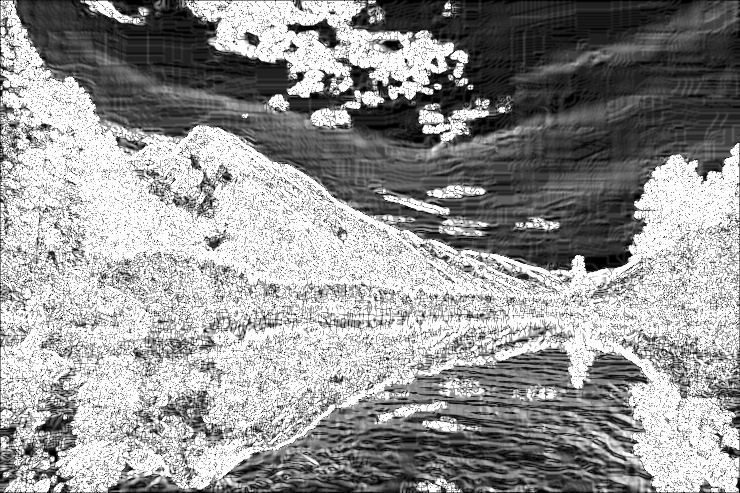

Sobel Combined (X and Y)


In [4]:
if img is not None:
    # Apply Sobel filter in X direction
    sobelx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=5) # dx=1, dy=0
    # Apply Sobel filter in Y direction
    sobely = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=5) # dx=0, dy=1

    # Compute the absolute value of the gradients
    abs_sobelx = cv2.convertScaleAbs(sobelx)
    abs_sobely = cv2.convertScaleAbs(sobely)

    # Combine the gradient images
    sobel_combined = cv2.addWeighted(abs_sobelx, 0.5, abs_sobely, 0.5, 0)

    print("Sobel filter applied and results displayed:")
    cv2_imshow(abs_sobelx)
    cv2.waitKey(0)
    print("Sobel X (absolute)")

    cv2_imshow(abs_sobely)
    cv2.waitKey(0)
    print("Sobel Y (absolute)")

    cv2_imshow(sobel_combined)
    cv2.waitKey(0)
    print("Sobel Combined (X and Y)")

    cv2.destroyAllWindows()
else:
    print("Cannot apply Sobel filter, image not loaded.")